In [2]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq
import pyarrow as pa
import numpy as np
import matplotlib.pyplot as plt

pd.options.display.float_format = "{:,.2f}".format


In [6]:
import os
os.getcwd()

'/home/psaengsouvanna/teams/z2/data/steam/notebooks'

In [9]:
file_path = "../data/final/all_reviews_clean_v2.parquet"
pf = pq.ParquetFile(file_path)

In [10]:
pf.metadata.num_rows

113883717

In [11]:
pf.metadata.num_row_groups

165

In [23]:
row_groups = [
    pf.metadata.row_group(i).num_rows
    for i in range(pf.metadata.num_row_groups)
]

pd.Series(row_groups).describe()


count         165.00
mean      690,204.35
std       160,202.90
min        63,527.00
25%       619,072.00
50%       688,982.00
75%       755,004.00
max     1,048,576.00
dtype: float64

In [24]:
#storage level EDA: parquet has 165 storage blocks with avg row group size of about 690K rows

In [12]:
pf.schema
pf.schema.names


['recommendationid',
 'appid',
 'game',
 'author_steamid',
 'author_num_games_owned',
 'author_num_reviews',
 'author_playtime_forever',
 'author_playtime_last_two_weeks',
 'author_playtime_at_review',
 'author_last_played',
 'language',
 'review',
 'timestamp_created',
 'timestamp_updated',
 'voted_up',
 'votes_up',
 'votes_funny',
 'weighted_vote_score',
 'comment_count',
 'steam_purchase',
 'received_for_free',
 'written_during_early_access',
 'hidden_in_steam_china',
 'steam_china_location']

In [26]:
import pyarrow.parquet as pq

pf = pq.ParquetFile(file_path)

cols = pf.schema.names[:12] 
rg0 = pf.read_row_group(0, columns=cols).to_pandas()

rg0.shape
rg0.head()



,recommendationid,appid,game,author_steamid,author_num_games_owned,author_num_reviews,author_playtime_forever,author_playtime_last_two_weeks,author_playtime_at_review,author_last_played,language,review
0,148919893,10,Counter-Strike,76561199036724879,0,3,197,197,197,2023-10-26 16:06:09,russian,старость
1,148919350,10,Counter-Strike,76561198826729322,0,21,441,37,441,2023-10-26 15:56:49,russian,Лучше кс 2
2,148913051,10,Counter-Strike,76561199101237625,7,1,1440,1440,1313,2023-10-26 16:43:55,turkish,çoh iyi ama pahalı
3,148912714,10,Counter-Strike,76561198347582422,11,4,1636,83,1612,2023-10-26 17:37:14,russian,топ
4,148912575,10,Counter-Strike,76561198363716821,0,2,197,41,197,2023-10-26 14:10:01,english,GOAT Game !!


In [29]:
#filters out text, lists, etc that will crash kernel
safe_cols = []
schema = pf.schema_arrow
for name in schema.names:
    t = schema.field(name).type
    if (
        pa.types.is_integer(t)
        or pa.types.is_floating(t)
        or pa.types.is_boolean(t)
        or pa.types.is_timestamp(t)
        or pa.types.is_date(t)
    ):
        safe_cols.append(name)

len(safe_cols), safe_cols[:15]


(19,
 ['recommendationid',
  'appid',
  'author_num_games_owned',
  'author_num_reviews',
  'author_playtime_forever',
  'author_playtime_last_two_weeks',
  'author_playtime_at_review',
  'author_last_played',
  'timestamp_created',
  'timestamp_updated',
  'voted_up',
  'votes_up',
  'votes_funny',
  'weighted_vote_score',
  'comment_count'])

In [30]:
excluded = []
for name in schema.names:
    t = schema.field(name).type
    if name not in safe_cols:
        excluded.append((name, str(t)))

excluded[:10]


[('game', 'string'),
 ('author_steamid', 'string'),
 ('language', 'string'),
 ('review', 'string'),
 ('steam_china_location', 'string')]

In [14]:
cols = [
    "recommendationid",
    "appid",
    "author_num_games_owned",
    "author_num_reviews",
    "author_playtime_forever",
    "author_playtime_last_two_weeks",
    "author_playtime_at_review",
    "author_last_played",
    "timestamp_created",
    "timestamp_updated",
    "voted_up",
    "votes_up",
    "votes_funny",
    "weighted_vote_score",
    "comment_count",
]

chunks = []
seen = 0

for batch in pf.iter_batches(batch_size=20_000, columns=cols):
    dfb = batch.to_pandas()
    chunks.append(dfb)
    seen += len(dfb)
    if seen >= 50_000:
        break

sample_df = pd.concat(chunks, ignore_index=True)
sample_df.shape


(60000, 15)

In [15]:
#sanity check
sample_df.info()
sample_df.nunique()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype         
---  ------                          --------------  -----         
 0   recommendationid                60000 non-null  Int64         
 1   appid                           60000 non-null  Int32         
 2   author_num_games_owned          60000 non-null  Int64         
 3   author_num_reviews              60000 non-null  Int64         
 4   author_playtime_forever         60000 non-null  Int64         
 5   author_playtime_last_two_weeks  60000 non-null  Int64         
 6   author_playtime_at_review       60000 non-null  Int64         
 7   author_last_played              60000 non-null  datetime64[ns]
 8   timestamp_created               60000 non-null  datetime64[ns]
 9   timestamp_updated               60000 non-null  datetime64[ns]
 10  voted_up                        60000 non-null  bool          
 11  vo

recommendationid                  60000
appid                                 1
author_num_games_owned              996
author_num_reviews                  369
author_playtime_forever           25768
author_playtime_last_two_weeks     2762
author_playtime_at_review         21010
author_last_played                59535
timestamp_created                 59928
timestamp_updated                 59926
voted_up                              2
votes_up                            201
votes_funny                          77
weighted_vote_score                2951
comment_count                        19
dtype: int64

reccomendationid = 60,000 
    - every row has a unique ID 
    - confrims sample has 60,000 unique distinct reviews
appid = 1
    *entire sample comes from ONE game 
    - streamed from early row groups 

Initial EDA was conducted on a 60,000 subset corresponding to a single game, due to Parquet row - group ordering. The dataset contains unique review-level records with rich user engagement signals, but the current streamed sample is drawn from a single application, highlighting the importance of controlled sampling when performing cross-game analysis.

AKA now need to sample across row groups, not just rows



In [16]:

cols = [
    "recommendationid",
    "appid",
    "author_num_games_owned",
    "author_num_reviews",
    "author_playtime_forever",
    "author_playtime_last_two_weeks",
    "author_playtime_at_review",
    "author_last_played",
    "timestamp_created",
    "timestamp_updated",
    "voted_up",
    "votes_up",
    "votes_funny",
    "weighted_vote_score",
    "comment_count",
]

def sample_across_row_groups(pf, cols, total_rows=60_000, n_groups=30, seed=42):
    rng = np.random.default_rng(seed)
    nrg_total = pf.metadata.num_row_groups
    
    # pick row groups spread across the file
    chosen = rng.choice(nrg_total, size=min(n_groups, nrg_total), replace=False)

    per_group = max(1, total_rows // len(chosen))
    chunks = []

    for i in chosen:
        # read one row group at a time (bounded memory)
        df_rg = pf.read_row_group(int(i), columns=cols).to_pandas()

        # sample from that row group (or take all if small)
        if len(df_rg) > per_group:
            df_rg = df_rg.sample(per_group, random_state=seed)

        chunks.append(df_rg)

    out = pd.concat(chunks, ignore_index=True)

    # final cap / shuffle
    if len(out) > total_rows:
        out = out.sample(total_rows, random_state=seed).reset_index(drop=True)
    else:
        out = out.sample(frac=1, random_state=seed).reset_index(drop=True)

    return out

sample_df = sample_across_row_groups(pf, cols, total_rows=60_000, n_groups=30, seed=42)

sample_df.shape, sample_df["appid"].nunique(), sample_df["appid"].head()


((60000, 15),
 2944,
 0    1446780
 1     261570
 2     248610
 3     115210
 4    1151340
 Name: appid, dtype: Int32)

In [17]:
(sample_df.shape,
 sample_df["appid"].nunique(),
 sample_df["appid"].value_counts().head())


((60000, 15),
 2944,
 appid
 730       6000
 440       2184
 271590    2000
 4000      1637
 359550    1623
 Name: count, dtype: Int64)

Now have 2944 distinct games. Top apps: CSGO with 6k reviews, Team Fortress 2 with 2184 reviews, GTA V with 2k reviews, etc. Popular games generate more reviews by nature and the sample preserves that structure. We may want to rebalance later for model training. 

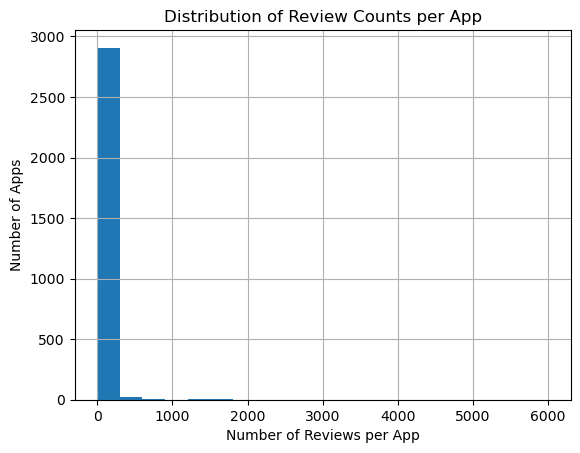

In [18]:
sample_df.groupby("appid").size().hist(bins=20)

plt.title("Distribution of Review Counts per App")
plt.xlabel("Number of Reviews per App")
plt.ylabel("Number of Apps")

plt.show()

- Unhelpful. Most apps crammed to the left. A few giant apps stretch the x axis. 

The x-axis reaches ~6000 because it shows reviews per app, not the number of apps — a single popular game can have thousands of reviews even though there are only 2,944 apps total.

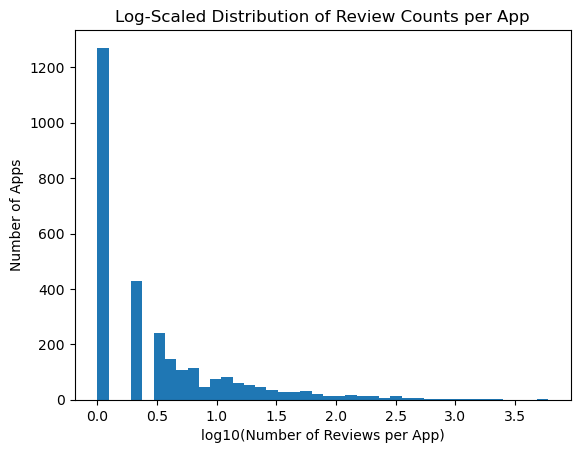

In [45]:


plt.hist(np.log10(counts), bins=40)
plt.title("Log-Scaled Distribution of Review Counts per App")
plt.xlabel("log10(Number of Reviews per App)")
plt.ylabel("Number of Apps")

plt.show()


Performing a log transformation visualizes the data better and shows a better spread. 
- Still shows a heavy right tailed distribution
  

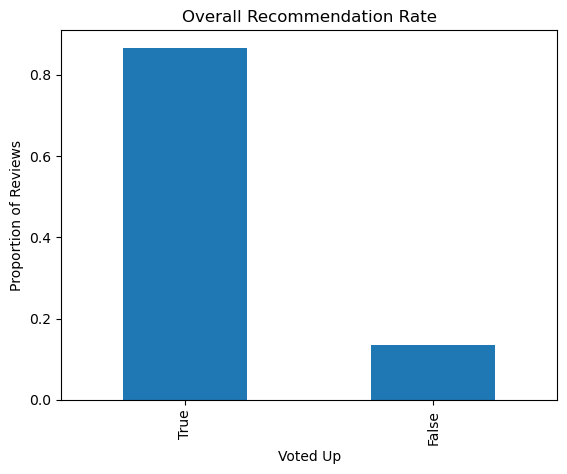

In [49]:
sample_df["voted_up"].value_counts(normalize=True).plot(kind="bar")
plt.title("Overall Recommendation Rate")
plt.xlabel("Voted Up")
plt.ylabel("Proportion of Reviews")
plt.show()


Most reviews seem to be postive. Sets expecations for modelling and reveals the imbalances early. 

/tmp/ipykernel_387/1458396445.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_df.groupby("popularity_tier")["voted_up"].mean().plot(kind="bar")


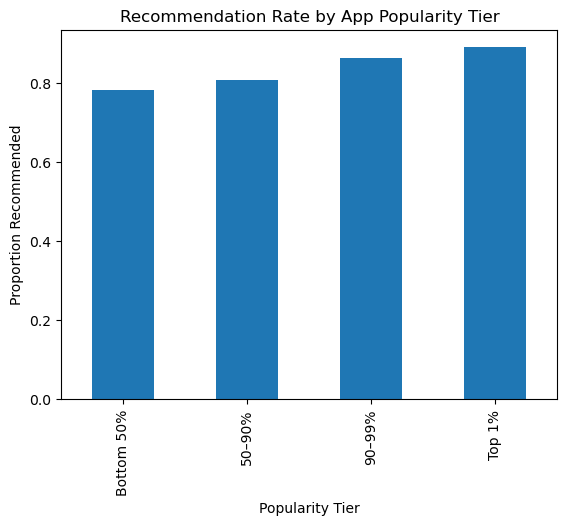

In [50]:
counts = sample_df.groupby("appid").size()

tiers = pd.qcut(
    counts,
    q=[0, .5, .9, .99, 1.0],
    labels=["Bottom 50%", "50–90%", "90–99%", "Top 1%"]
)

tier_df = sample_df.assign(popularity_tier=sample_df["appid"].map(tiers))

tier_df.groupby("popularity_tier")["voted_up"].mean().plot(kind="bar")
plt.title("Recommendation Rate by App Popularity Tier")
plt.xlabel("Popularity Tier")
plt.ylabel("Proportion Recommended")
plt.show()


Question: Do popular games get better reviews? Can show show structural bias - but seems to be decently balanced across groups. 

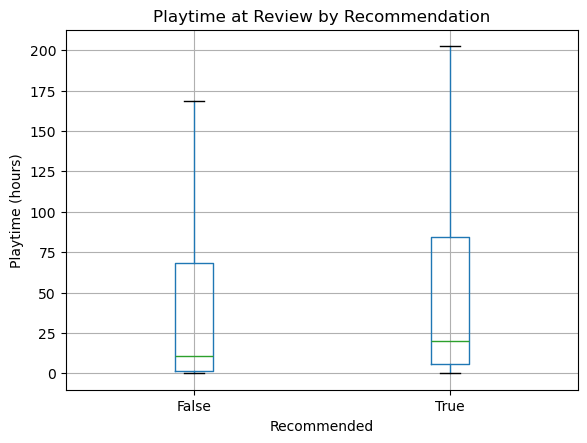

In [51]:
sample_df["playtime_hours"] = sample_df["author_playtime_at_review"] / 60

sample_df.boxplot(
    column="playtime_hours",
    by="voted_up",
    showfliers=False
)
plt.title("Playtime at Review by Recommendation")
plt.suptitle("")
plt.xlabel("Recommended")
plt.ylabel("Playtime (hours)")
plt.show()


Question : Do people who play more reccomend more ? 
- Median playtime is higher for reccomended reviews
- Users who reccomend a game tend to have aobut double the playtime at the time of the review.
- Heavy right tail for both groups
    - Both distributions have long whiskers extending beyoond 150 hours (false) and 200 hours (true)
    - some players invest hundreds of hours and still leave negative reviews
    - playtime alone does not fully determine sentiment
      
IQR is wider for reccoemedned reviews and longer upper tail
  - Non reccomended reviewsare more tightly clustered at lower playtime

Despite different medians, there is overlap between the two boxes.
Many users with low playtime reccomend and some users with high playtime do not reccomend. 

Positive reviews come from both moderately engaged and highly engaged players. Negative reviews are more concentrated among low to moderate playtime users. Reccomendation behavior reflects player investment, genre preferences, expectations, updates, design choices, etc. Playtime is a strong bhevaior signal, but is not a decisive tool to alone to determine reccomendation behavior.



/tmp/ipykernel_387/2706605271.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  sample_df.set_index("created_dt").resample("M").size().plot()


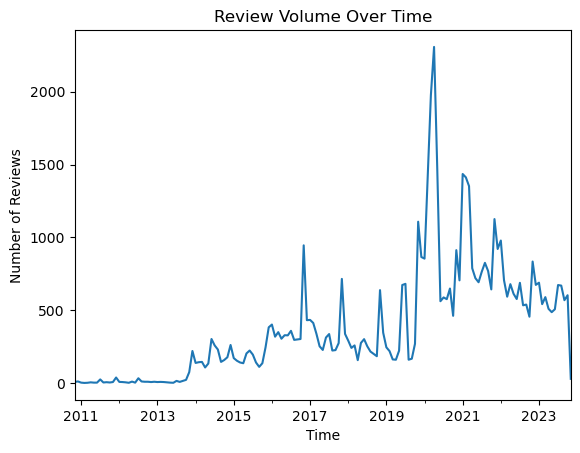

In [54]:
sample_df["created_dt"] = pd.to_datetime(sample_df["timestamp_created"], unit="s")

sample_df.set_index("created_dt").resample("M").size().plot()
plt.title("Review Volume Over Time")
plt.xlabel("Time")
plt.ylabel("Number of Reviews")
plt.show()




Question: When are reviews happening?
- early 2011-2013 reflects early user activity / limited coverage
- gradual growth 2014- 2019 -> upward growth but still noisy
- 2020-2021 larger spikes -> likely driven by external circumstances aka covid-era surge (confounding factor)
- 2021-2023 declines from peak, but does not return to early levels 

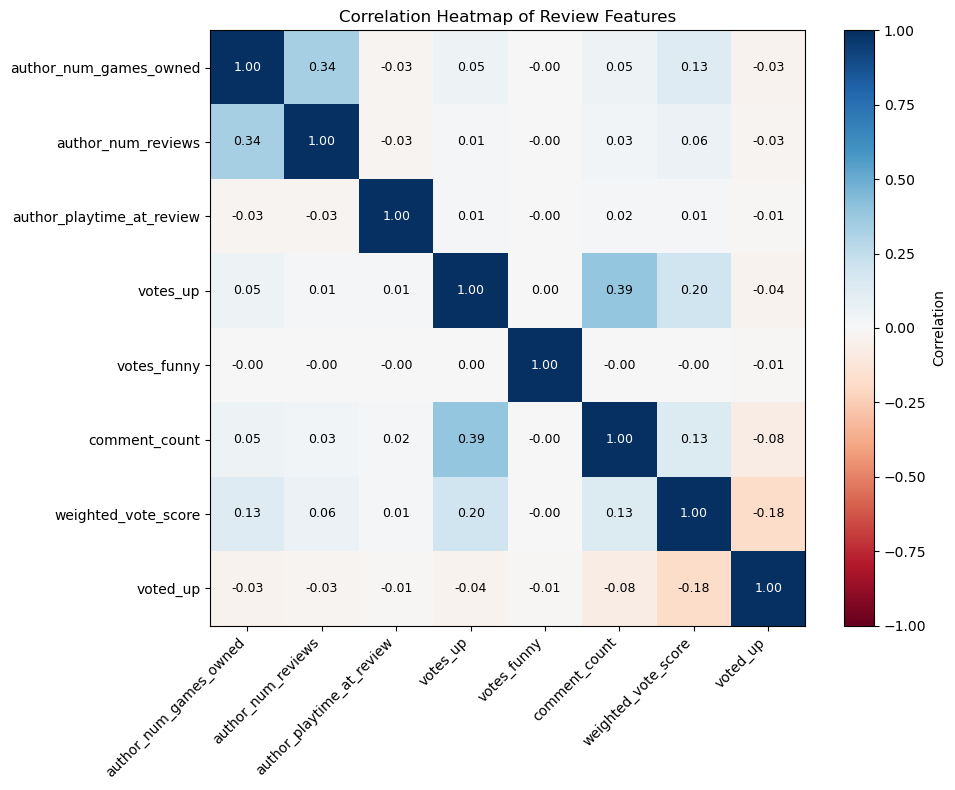

In [60]:
cols = [
    "author_num_games_owned",
    "author_num_reviews",
    "author_playtime_at_review",
    "votes_up",
    "votes_funny",
    "comment_count",
    "weighted_vote_score",
    "voted_up",
]
corr = sample_df[cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(
    corr,
    cmap="RdBu",      # blue ↔ red
    vmin=-1,
    vmax=1
)

# ticks & labels
ax.set_xticks(np.arange(len(cols)))
ax.set_yticks(np.arange(len(cols)))
ax.set_xticklabels(cols, rotation=45, ha="right")
ax.set_yticklabels(cols)


for i in range(len(cols)):
    for j in range(len(cols)):
        ax.text(
            j, i,
            f"{corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="white" if abs(corr.iloc[i, j]) > 0.5 else "black",
            fontsize=9
        )

# colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Correlation")

plt.title("Correlation Heatmap of Review Features")
plt.tight_layout()
plt.show()

Notable Relationships:
author_num_reviews and author_num_games_owned 0.34
votes_up and comment_count 0.39
weighted_vote_score and voted_up 0.18

Overall, not many very strong linear relationships. 